# v1 Primary Model - LightGBM

Ridge baseline established, read from MLflow (best run by val_mae).

Key differences from Ridge:
- No scaling required (tree splits are scale-invariant)
- No imputation required (LightGBM learns from NaN)
- Android media NaN set to 0
- Early stopping on val set prevents overfitting

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../")))

import mlflow
import mlflow.lightgbm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from src.models.train_v1 import train_lightgbm, load_v1_splits
from src.features.feature_columns import SENSING_FEATURES, TARGET

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mental_health_prediction")
os.environ["MLFLOW_ARTIFACT_UPLOAD_DOWNLOAD_TIMEOUT"] = "300"

client = mlflow.tracking.MlflowClient()
ridge_runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` LIKE 'v1_ridge_alpha_%'",
    order_by=["metrics.val_mae ASC"],
    max_results=1
)

if not ridge_runs:
    raise RuntimeError("No Ridge runs found in MLflow. Run notebook 01 first.")

RIDGE_BASELINE_VAL_MAE = ridge_runs[0].data.metrics["val_mae"]
RIDGE_BASELINE_TEST_MAE = ridge_runs[0].data.metrics["test_mae"]
RIDGE_BASELINE_VAL_R2 = ridge_runs[0].data.metrics["val_r2"]
best_ridge_run_name = ridge_runs[0].data.tags.get("mlflow.runName", "unknown")

print(f"Ridge baseline (from MLflow run '{best_ridge_run_name}'):")
print(f"  val MAE  : {RIDGE_BASELINE_VAL_MAE:.4f}")
print(f"  test MAE : {RIDGE_BASELINE_TEST_MAE:.4f}")
print(f"  val R2   : {RIDGE_BASELINE_VAL_R2:.4f}")
print(f"Features: {len(SENSING_FEATURES)}")

Ridge baseline (from MLflow run 'v1_ridge_alpha_0.1'):
  val MAE  : 9.8925
  test MAE : 10.5306
  val R2   : 0.3789
Features: 22


In [2]:
train, val, test = load_v1_splits()

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")
print(f"\nLabel mean — Train: {train[TARGET].mean():.1f} | "
      f"Val: {val[TARGET].mean():.1f} | Test: {test[TARGET].mean():.1f}")
print(f"Label std  — Train: {train[TARGET].std():.1f} | "
      f"Val: {val[TARGET].std():.1f} | Test: {test[TARGET].std():.1f}")

print(f"\nNaN counts in training features (after Android fix applied in train_lightgbm):")
nan_counts = train[SENSING_FEATURES].isna().sum()
print(nan_counts[nan_counts > 0])

Train: 6,940 | Val: 1,610 | Test: 1,381

Label mean — Train: 64.8 | Val: 64.1 | Test: 63.6
Label std  — Train: 15.8 | Val: 16.2 | Test: 16.4

NaN counts in training features (after Android fix applied in train_lightgbm):
label_lag1                          206
other_playing_duration_ep_0_mean    409
other_playing_duration_ep_0_std     410
dtype: int64


In [3]:
# Default hyperparameters first
model_default, metrics_default = train_lightgbm(
    n_estimators=1000,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    min_child_samples=20,
    run_name="v1_lgbm_default"
)

print(f"\nComparison:")
print(f"  Ridge    val MAE: {RIDGE_BASELINE_VAL_MAE}")
print(f"  LightGBM val MAE: {metrics_default['val_mae']}")
improvement = RIDGE_BASELINE_VAL_MAE - metrics_default['val_mae']
print(f"  Improvement     : {improvement:.4f} ({improvement/RIDGE_BASELINE_VAL_MAE*100:.1f}%)")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000826 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

2026/04/13 02:40:39 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_default at: http://localhost:5000/#/experiments/2/runs/6b57d0ca8dc348c49097ef86231b7d3c
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=69)
  train MAE: 8.9649  R2: 0.4722
  val   MAE: 9.9567   R2: 0.3582
  test  MAE: 10.6583   R2: 0.2967

Comparison:
  Ridge    val MAE: 9.8925
  LightGBM val MAE: 9.9567
  Improvement     : -0.0642 (-0.6%)


In [4]:
configs = [
    {"learning_rate": 0.01,  "max_depth": 4, "num_leaves": 15, "min_child_samples": 20},
    {"learning_rate": 0.01,  "max_depth": 6, "num_leaves": 31, "min_child_samples": 20},
    {"learning_rate": 0.05,  "max_depth": 4, "num_leaves": 15, "min_child_samples": 10},
    {"learning_rate": 0.05,  "max_depth": 6, "num_leaves": 31, "min_child_samples": 10},
    {"learning_rate": 0.05,  "max_depth": 8, "num_leaves": 63, "min_child_samples": 20},
    {"learning_rate": 0.1,   "max_depth": 4, "num_leaves": 15, "min_child_samples": 20},
]

tuning_results = []

for i, cfg in enumerate(configs):
    _, metrics = train_lightgbm(
        **cfg,
        n_estimators=1000,
        run_name=f"v1_lgbm_tune_{i}"
    )
    tuning_results.append({**cfg, **metrics})
    print(f"Config {i}: lr={cfg['learning_rate']}, depth={cfg['max_depth']}, "
          f"leaves={cfg['num_leaves']} → val_mae={metrics['val_mae']:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values("val_mae")
print(f"\nTop 3 configurations by val_mae:")
print(tuning_df[["learning_rate", "max_depth", "num_leaves",
                  "min_child_samples", "val_mae", "test_mae"]].head(3).to_string(index=False))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000766 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

2026/04/13 02:40:51 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_0 at: http://localhost:5000/#/experiments/2/runs/1c12bea6460c44daafbe6ee117d2b2a0
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=381)
  train MAE: 9.5176  R2: 0.4034
  val   MAE: 9.9468   R2: 0.3664
  test  MAE: 10.6078   R2: 0.3039
Config 0: lr=0.01, depth=4, leaves=15 → val_mae=9.9468
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

2026/04/13 02:41:00 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_1 at: http://localhost:5000/#/experiments/2/runs/516072292ab84888a230957bb474aba8
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=348)
  train MAE: 8.9623  R2: 0.4723
  val   MAE: 9.9617   R2: 0.3597
  test  MAE: 10.6492   R2: 0.2982
Config 1: lr=0.01, depth=6, leaves=31 → val_mae=9.9617
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

...

🏃 View run v1_lgbm_tune_3 at: http://localhost:5000/#/experiments/2/runs/7da3770bb76f4f39a3b12690e004affd
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=71)
  train MAE: 8.9095  R2: 0.4807
  val   MAE: 10.0066   R2: 0.3564
  test  MAE: 10.6289   R2: 0.3005
Config 3: lr=0.05, depth=6, leaves=31 → val_mae=10.0066
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

2026/04/13 02:41:40 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_4 at: http://localhost:5000/#/experiments/2/runs/e4b60c36537d4d01abcbd825dbbae83e
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=69)
  train MAE: 8.0729  R2: 0.5708
  val   MAE: 10.0258   R2: 0.3515
  test  MAE: 10.7492   R2: 0.2862
Config 4: lr=0.05, depth=8, leaves=63 → val_mae=10.0258
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

2026/04/13 02:41:49 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_tune_5 at: http://localhost:5000/#/experiments/2/runs/7dc9456f807f4a3798eca8450e3c7280
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=50)
  train MAE: 9.3879  R2: 0.4185
  val   MAE: 9.9133   R2: 0.3706
  test  MAE: 10.5936   R2: 0.3058
Config 5: lr=0.1, depth=4, leaves=15 → val_mae=9.9133

Top 3 configurations by val_mae:
 learning_rate  max_depth  num_leaves  min_child_samples  val_mae  test_mae
          0.10          4          15                 20   9.9133   10.5936
          0.01          4          15                 20   9.9468   10.6078
          0.05          4          15                 10   9.9567   10.5927


Best config: lr=0.1, depth=4.0, leaves=15.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5329
[LightGBM] [Info] Number of data points in the train set: 6940, number of used features: 22
[LightGBM] [Info] Start training from score 64.840880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

2026/04/13 02:41:59 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v1_lgbm_best at: http://localhost:5000/#/experiments/2/runs/09a6e120b54b4b358cdb888b6951ed04
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM (best_iteration=50)
  train MAE: 9.3879  R2: 0.4185
  val   MAE: 9.9133   R2: 0.3706
  test  MAE: 10.5936   R2: 0.3058


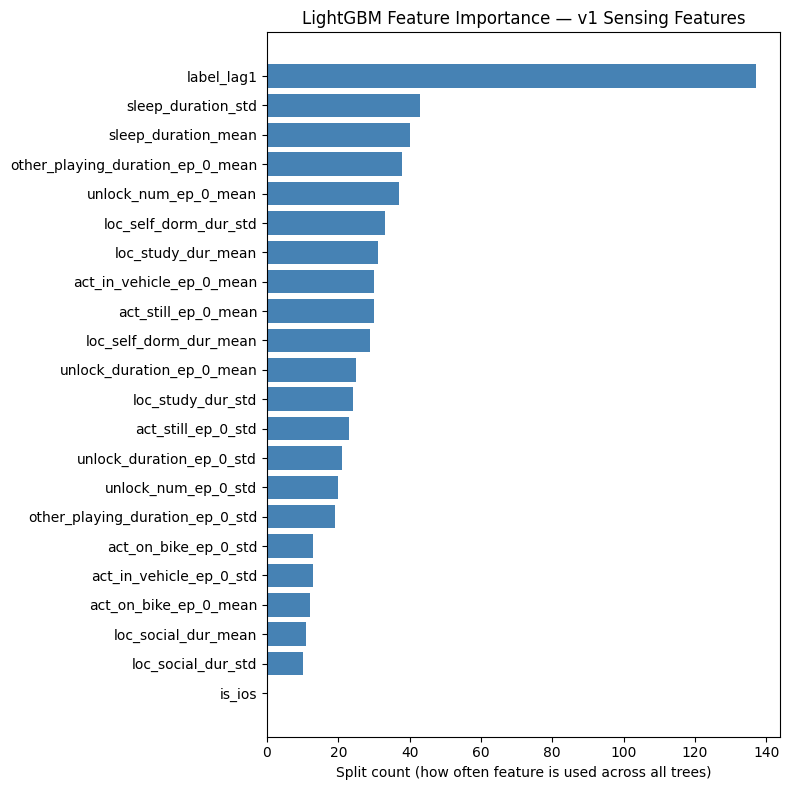


Top 5 most important features:
                         feature  importance
                      label_lag1         137
              sleep_duration_std          43
             sleep_duration_mean          40
other_playing_duration_ep_0_mean          38
            unlock_num_ep_0_mean          37


In [5]:
best_config = tuning_df.iloc[0]
print(f"Best config: lr={best_config['learning_rate']}, "
      f"depth={best_config['max_depth']}, leaves={best_config['num_leaves']}")

# Retrain best config 
best_model, best_metrics = train_lightgbm(
    learning_rate=float(best_config["learning_rate"]),
    max_depth=int(best_config["max_depth"]),
    num_leaves=int(best_config["num_leaves"]),
    min_child_samples=int(best_config["min_child_samples"]),
    n_estimators=1000,
    run_name="v1_lgbm_best"
)

# Plot feature importance
fi = pd.DataFrame({
    "feature":    SENSING_FEATURES,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(fi["feature"], fi["importance"], color="steelblue")
ax.set_xlabel("Split count (how often feature is used across all trees)")
ax.set_title("LightGBM Feature Importance — v1 Sensing Features")
plt.tight_layout()
plt.savefig("../../outputs/figures/v1_lgbm_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(fi.sort_values("importance", ascending=False).head(5).to_string(index=False))

In [6]:
print("=" * 60)
print("MODEL COMPARISON — v1 PRE-COVID DATA (with lag feature)")
print("=" * 60)
print(f"\n{'Model':<30} {'val MAE':>10} {'test MAE':>10} {'val R2':>8}")
print("-" * 60)
print(f"{'Ridge (best alpha, with lag)':30} "
      f"{RIDGE_BASELINE_VAL_MAE:>10.4f} "
      f"{RIDGE_BASELINE_TEST_MAE:>10.4f} "
      f"{RIDGE_BASELINE_VAL_R2:>8.4f}")
print(f"{'LightGBM (best, with lag)':30} "
      f"{best_metrics['val_mae']:>10.4f} "
      f"{best_metrics['test_mae']:>10.4f} "
      f"{best_metrics['val_r2']:>8.4f}")
print()

improvement_val = RIDGE_BASELINE_VAL_MAE - best_metrics["val_mae"]
improvement_pct = improvement_val / RIDGE_BASELINE_VAL_MAE * 100
print(f"LightGBM improvement over Ridge: {improvement_val:+.4f} MAE "
      f"({improvement_pct:+.1f}%)")
print()

if improvement_val > 0.1:
    print("LightGBM outperforms Ridge — proceed to registration.")
elif improvement_val > 0:
    print("LightGBM marginally outperforms Ridge.")
else:
    print("Ridge matches or outperforms LightGBM on this data.")
    print("LightGBM still used as primary model for v2 NaN handling.")


MODEL COMPARISON — v1 PRE-COVID DATA (with lag feature)

Model                             val MAE   test MAE   val R2
------------------------------------------------------------
Ridge (best alpha, with lag)       9.8925    10.5306   0.3789
LightGBM (best, with lag)          9.9133    10.5936   0.3706

LightGBM improvement over Ridge: -0.0208 MAE (-0.2%)

Ridge matches or outperforms LightGBM on this data.
LightGBM still used as primary model for v2 NaN handling.


In [7]:
# Register best v1 LightGBM in MLflow Model Registry
client = mlflow.tracking.MlflowClient()

lgbm_best_runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` = 'v1_lgbm_best'",
    order_by=["metrics.val_mae ASC"],
    max_results=1
)

if not lgbm_best_runs:
    raise RuntimeError("v1_lgbm_best run not found.")

best_run_id = lgbm_best_runs[0].info.run_id
model_uri = f"runs:/{best_run_id}/model"

registered = mlflow.register_model(model_uri, "mental_health_v1")

client.set_registered_model_alias(
    name="mental_health_v1",
    alias="production",
    version=registered.version
)

print(f"Registered: mental_health_v1 v{registered.version} to Production")
print(f"Run ID    : {best_run_id}")
print(f"Val MAE   : {best_metrics['val_mae']:.4f}")
print(f"Test MAE  : {best_metrics['test_mae']:.4f}")
print(f"Val R2    : {best_metrics['val_r2']:.4f}")

Registered model 'mental_health_v1' already exists. Creating a new version of this model...
2026/04/13 02:42:10 WARNING mlflow.tracking._model_registry.fluent: Run with id 09a6e120b54b4b358cdb888b6951ed04 has no artifacts at artifact path 'model', registering model based on models:/m-47e1a1b85b6c46049876074c72c5671a instead
2026/04/13 02:42:10 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: mental_health_v1, version 5
Created version '5' of model 'mental_health_v1'.


Registered: mental_health_v1 v5 to Production
Run ID    : 09a6e120b54b4b358cdb888b6951ed04
Val MAE   : 9.9133
Test MAE  : 10.5936
Val R2    : 0.3706


In [9]:
import json

train = pd.read_csv("../../data/processed/splits/pre_covid_train.csv")
baseline_stats = {}
for col in SENSING_FEATURES:
    baseline_stats[col] = {
        "mean": float(train[col].mean()),
        "std":  float(train[col].std()),
        "p5":   float(train[col].quantile(0.05)),
        "p95":  float(train[col].quantile(0.95)),
    }

with open("../../outputs/reports/v1_feature_baseline.json", "w") as f:
    json.dump(baseline_stats, f, indent=2)

print("Feature baseline saved: outputs/reports/v1_feature_baseline.json")

Feature baseline saved: outputs/reports/v1_feature_baseline.json
